# GBIF & Climate DT — *Quercus robur* Habitat Shift

This notebook combines species occurrence data from [GBIF](https://www.gbif.org/) with 2 m temperature output from the Destination Earth Climate DT to explore how the thermal habitat of *Quercus robur* (pedunculate oak) may shift under the SSP3-7.0 future climate scenario.

**Three parts:**

1. **GBIF occurrences** — fetch *Quercus robur* observation counts per European country via the GBIF occurrence search API (`pygbif`) and plot as a choropleth.
2. **Climate DT temperatures** — load JJA (June–August) mean 2 m temperature per country from cached Climate DT files for the historical baseline (2005–2014) and the SSP3-7.0 future scenario (2040–2049).
3. **Habitat shift map** — characterise each country as *current range*, *range expansion* (future temperature enters the species' observed thermal envelope), *range loss* (future temperature exits the envelope), or *outside range*, and plot the shift.

---
## Part 1 — GBIF: *Quercus robur* occurrences per country

In [8]:
%pip install pygbif --quiet

import os, sys
# Point PROJ at the data bundled with pyogrio in this venv
_venv = os.path.dirname(sys.executable)
os.environ.setdefault(
    "PROJ_DATA",
    os.path.join(_venv, "..", "lib", "python3.11", "site-packages", "pyogrio", "proj_data")
)

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.patches as mpatches
import earthkit.plots
from pygbif import species as gbif_species, occurrences as gbif_occ

/Users/maaw/github/polytope-examples/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [9]:
# Countries to include — same list as eurostat_visualisation.ipynb
# (geo_code, Natural-Earth country name)
COUNTRY_NAMES = [
    ("BE", "Belgium"),
    ("BG", "Bulgaria"),
    ("CZ", "Czech Republic"),
    ("DK", "Denmark"),
    ("DE", "Germany"),
    ("EE", "Estonia"),
    ("EL", "Greece"),
    ("ES", "Spain"),
    ("FR", "France"),
    ("HR", "Croatia"),
    ("IT", "Italy"),
    ("CY", "Cyprus"),
    ("LV", "Latvia"),
    ("LT", "Lithuania"),
    ("LU", "Luxembourg"),
    ("HU", "Hungary"),
    ("NL", "Netherlands"),
    ("AT", "Austria"),
    ("PL", "Poland"),
    ("PT", "Portugal"),
    ("RO", "Romania"),
    ("SI", "Slovenia"),
    ("SK", "Slovakia"),
    ("FI", "Finland"),
    ("SE", "Sweden"),
    ("IS", "Iceland"),
    ("NO", "Norway"),
    ("CH", "Switzerland"),
]
country_codes = [c[0] for c in COUNTRY_NAMES]

# GBIF uses ISO 3166-1 alpha-2; NUTS uses the same codes except EL→GR
NUTS_TO_ISO = {"EL": "GR"}
ISO_TO_NUTS = {v: k for k, v in NUTS_TO_ISO.items()}

print(f"{len(COUNTRY_NAMES)} countries defined")

28 countries defined


In [10]:
# ── Resolve Quercus robur to its GBIF backbone taxon key ─────────────────────
SPECIES_NAME = "Quercus robur"
match = gbif_species.name_backbone(SPECIES_NAME, taxonRank="SPECIES")
taxon_key = match["usage"]["key"]
confidence = match.get("diagnostics", {}).get("confidence", "?")
status     = match["usage"].get("status", "?")
print(f"{SPECIES_NAME} → taxonKey {taxon_key} ({status}, {confidence}% confidence)")

Quercus robur → taxonKey 2878688 (ACCEPTED, 97% confidence)


In [11]:
# ── Fetch occurrence counts per country via GBIF search API ──────────────────
# Uses the anonymous search endpoint (no download, no auth required).
# limit=0 with country filter returns the total count without fetching records.
# A short sleep between requests avoids hitting the 429 rate limit.
import time

rows = []
for nuts_code, _ in COUNTRY_NAMES:
    iso_code = NUTS_TO_ISO.get(nuts_code, nuts_code)
    result = gbif_occ.search(taxonKey=taxon_key, country=iso_code, limit=0)
    count = result.get("count", 0)
    rows.append({"geo": nuts_code, "occurrences": count})
    print(f"  {nuts_code} ({iso_code}): {count:,} occurrences")
    time.sleep(0.5)

df_gbif = pd.DataFrame(rows)
print(f"\nTotal across all countries: {df_gbif['occurrences'].sum():,}")
df_gbif

  BE (BE): 52,645 occurrences
  BG (BG): 63 occurrences
  CZ (CZ): 8,294 occurrences
  DK (DK): 101,765 occurrences
  DE (DE): 260,734 occurrences
  EE (EE): 3,725 occurrences
  EL (GR): 89 occurrences
  ES (ES): 11,895 occurrences
  FR (FR): 324,428 occurrences
  HR (HR): 67 occurrences
  IT (IT): 1,586 occurrences
  CY (CY): 0 occurrences
  LV (LV): 336 occurrences
  LT (LT): 627 occurrences
  LU (LU): 4,195 occurrences
  HU (HU): 272 occurrences
  NL (NL): 190,294 occurrences
  AT (AT): 22,854 occurrences
  PL (PL): 46,190 occurrences
  PT (PT): 2,412 occurrences
  RO (RO): 182 occurrences
  SI (SI): 243 occurrences
  SK (SK): 3,578 occurrences
  FI (FI): 13,421 occurrences
  SE (SE): 212,822 occurrences
  IS (IS): 2 occurrences
  NO (NO): 19,803 occurrences
  CH (CH): 18,400 occurrences

Total across all countries: 1,300,922


,geo,occurrences
0,BE,52645
1,BG,63
2,CZ,8294
3,DK,101765
4,DE,260734
5,EE,3725
6,EL,89
7,ES,11895
8,FR,324428
9,HR,67


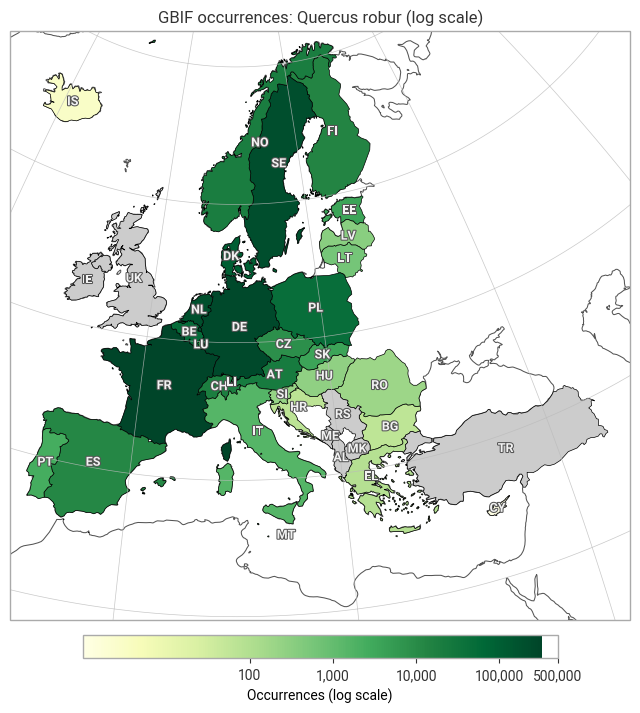

In [12]:
# ── Map: Quercus robur occurrence density ─────────────────────────────────────
shapefile_path = "data/NUTS_RG_20M_2021_4326_LEVL_0.shp.zip"
gdf = gpd.read_file(f"zip://{shapefile_path}")

cmap_gbif = plt.get_cmap("YlGn")

# Log-scale the counts for better colour contrast
log_counts = np.log1p(df_gbif["occurrences"].values)
norm_gbif = plt.Normalize(vmin=log_counts.min(), vmax=log_counts.max())

df_gbif["facecolor"] = [
    plt.cm.colors.to_hex(cmap_gbif(norm_gbif(v))) for v in log_counts
]

gdf_gbif = gdf.merge(df_gbif, left_on="NUTS_ID", right_on="geo", how="left")
if not isinstance(gdf_gbif, gpd.GeoDataFrame):
    gdf_gbif = gpd.GeoDataFrame(gdf_gbif, geometry=gdf.geometry, crs=gdf.crs)
gdf_gbif["facecolor"] = gdf_gbif["facecolor"].fillna("#cccccc")

chart = earthkit.plots.Map(domain="Europe")
chart.coastlines()
chart.shapes(
    shapefile_path,
    labels="NUTS_ID",
    facecolor=gdf_gbif["facecolor"],
    cmap="YlGn",
    edgecolor="black",
    linewidth=0.5,
)
chart.gridlines(draw_labels=False)
chart.title(f"GBIF occurrences: {SPECIES_NAME} (log scale)")

# Colorbar with real counts at tick positions
tick_counts = [100, 1_000, 10_000, 100_000, 500_000]
tick_log    = np.log1p(tick_counts)
sm = plt.cm.ScalarMappable(cmap="YlGn", norm=norm_gbif)
sm.set_array([])
cb = chart.fig.colorbar(sm, ax=chart.ax, orientation="horizontal",
                         pad=0.02, shrink=0.6, label="Occurrences (log scale)")
cb.set_ticks(tick_log)
cb.set_ticklabels([f"{c:,}" for c in tick_counts])
chart.show()

---
## Part 2 — Climate DT: JJA mean 2 m temperature per country

Temperatures are loaded from the locally cached `.covjson` files produced by `fetch_cdt_data.py`:
- **Historical baseline:** `hist` experiment, JJA months, 2005–2014
- **Future scenario:** `SSP3-7.0` experiment, JJA months, 2040–2049

Set `LIVE_REQUEST = True` to fetch directly from the Climate DT instead.

In [13]:
import earthkit.data
import earthkit.geo.cartography

LIVE_REQUEST   = False
HAZARD_PARAM   = "avg_2t"
HAZARD_MODEL   = "ifs-nemo"
HAZARD_ADDRESS = "polytope.mn5.apps.dte.destination-earth.eu"
JJA_MONTHS     = ["6", "7", "8"]
HIST_YEARS     = [str(y) for y in range(2005, 2015)]
FUTURE_YEARS   = [str(y) for y in range(2040, 2050)]

def make_hazard_request(shape, experiment, year, month):
    activity = "baseline" if experiment == "hist" else "projections"
    return {
        "activity":    activity,
        "class":       "d1",
        "dataset":     "climate-dt",
        "experiment":  experiment,
        "generation":  "2",
        "levtype":     "sfc",
        "year":        year,
        "month":       month,
        "model":       HAZARD_MODEL,
        "expver":      "0001",
        "param":       HAZARD_PARAM,
        "realization": "1",
        "resolution":  "standard",
        "stream":      "clmn",
        "type":        "fc",
        "feature": {
            "type":  "polygon",
            "shape": shape,
        },
    }

print("Config ready — LIVE_REQUEST =", LIVE_REQUEST)

Config ready — LIVE_REQUEST = False


In [14]:
# ── Load historical JJA temperatures (2005–2014) ──────────────────────────────
country_jja_hist = {geo: [] for geo, _ in COUNTRY_NAMES}

for geo_code, country_name in COUNTRY_NAMES:
    shape = earthkit.geo.cartography.country_polygons([country_name], resolution=50e6)
    for year in HIST_YEARS:
        for month in JJA_MONTHS:
            cache = f"data/hazard_hist_{geo_code}_{year}_{month.zfill(2)}.covjson"
            req = make_hazard_request(shape, "hist", year, month)
            if LIVE_REQUEST:
                raw = earthkit.data.from_source(
                    "polytope", "destination-earth", req,
                    address=HAZARD_ADDRESS, stream=False)
                raw.to_target("file", cache)
            else:
                raw = earthkit.data.from_source("file", cache)
            ds = raw.to_xarray()
            country_jja_hist[geo_code].append(float(np.nanmean(ds[HAZARD_PARAM].values)))
    print(f"  {geo_code}: {len(country_jja_hist[geo_code])} monthly values")

T_hist_K = np.array([np.nanmean(country_jja_hist[c]) for c in country_codes])
T_hist_C = T_hist_K - 273.15
print(f"\nHistorical JJA 2 m temp (°C): min={T_hist_C.min():.1f}, max={T_hist_C.max():.1f}")

  BE: 30 monthly values
  BG: 30 monthly values
  CZ: 30 monthly values
  DK: 30 monthly values
  DE: 30 monthly values
  EE: 30 monthly values
  EL: 30 monthly values
  ES: 30 monthly values
  FR: 30 monthly values
  HR: 30 monthly values
  IT: 30 monthly values
  CY: 30 monthly values
  LV: 30 monthly values
  LT: 30 monthly values
  LU: 30 monthly values
  HU: 30 monthly values
  NL: 30 monthly values
  AT: 30 monthly values
  PL: 30 monthly values
  PT: 30 monthly values
  RO: 30 monthly values
  SI: 30 monthly values
  SK: 30 monthly values
  FI: 30 monthly values
  SE: 30 monthly values
  IS: 30 monthly values
  NO: 30 monthly values
  CH: 30 monthly values

Historical JJA 2 m temp (°C): min=5.8, max=26.9


In [15]:
# ── Load SSP3-7.0 JJA temperatures (2040–2049) ───────────────────────────────
country_jja_future = {geo: [] for geo, _ in COUNTRY_NAMES}

for geo_code, country_name in COUNTRY_NAMES:
    shape = earthkit.geo.cartography.country_polygons([country_name], resolution=50e6)
    for year in FUTURE_YEARS:
        for month in JJA_MONTHS:
            cache = f"data/hazard_ssp370_{geo_code}_{year}_{month.zfill(2)}.covjson"
            req = make_hazard_request(shape, "SSP3-7.0", year, month)
            if LIVE_REQUEST:
                raw = earthkit.data.from_source(
                    "polytope", "destination-earth", req,
                    address=HAZARD_ADDRESS, stream=False)
                raw.to_target("file", cache)
            else:
                raw = earthkit.data.from_source("file", cache)
            ds = raw.to_xarray()
            country_jja_future[geo_code].append(float(np.nanmean(ds[HAZARD_PARAM].values)))
    print(f"  {geo_code}: {len(country_jja_future[geo_code])} monthly values")

T_future_K = np.array([np.nanmean(country_jja_future[c]) for c in country_codes])
T_future_C = T_future_K - 273.15
print(f"\nFuture JJA 2 m temp (°C): min={T_future_C.min():.1f}, max={T_future_C.max():.1f}")

  BE: 30 monthly values
  BG: 30 monthly values
  CZ: 30 monthly values
  DK: 30 monthly values
  DE: 30 monthly values
  EE: 30 monthly values
  EL: 30 monthly values
  ES: 30 monthly values
  FR: 30 monthly values
  HR: 30 monthly values
  IT: 30 monthly values
  CY: 30 monthly values
  LV: 30 monthly values
  LT: 30 monthly values
  LU: 30 monthly values
  HU: 30 monthly values
  NL: 30 monthly values
  AT: 30 monthly values
  PL: 30 monthly values
  PT: 30 monthly values
  RO: 30 monthly values
  SI: 30 monthly values
  SK: 30 monthly values
  FI: 30 monthly values
  SE: 30 monthly values
  IS: 30 monthly values
  NO: 30 monthly values
  CH: 30 monthly values

Future JJA 2 m temp (°C): min=6.9, max=28.2


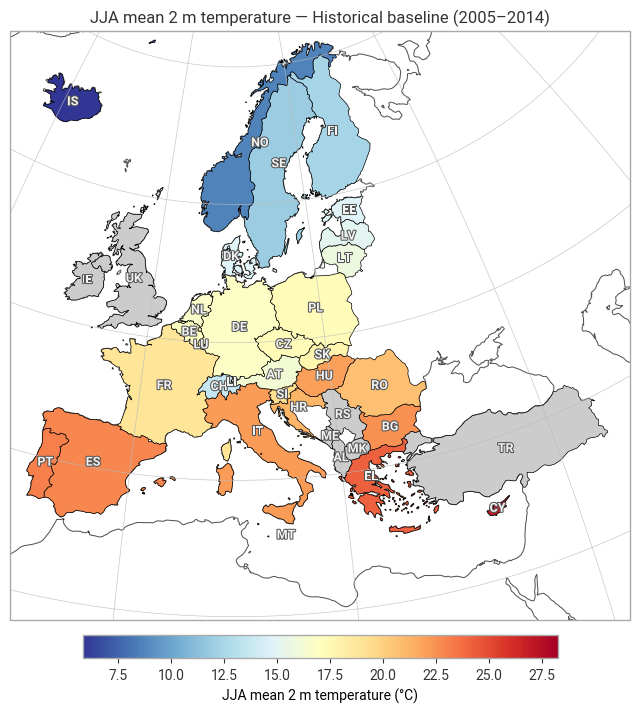

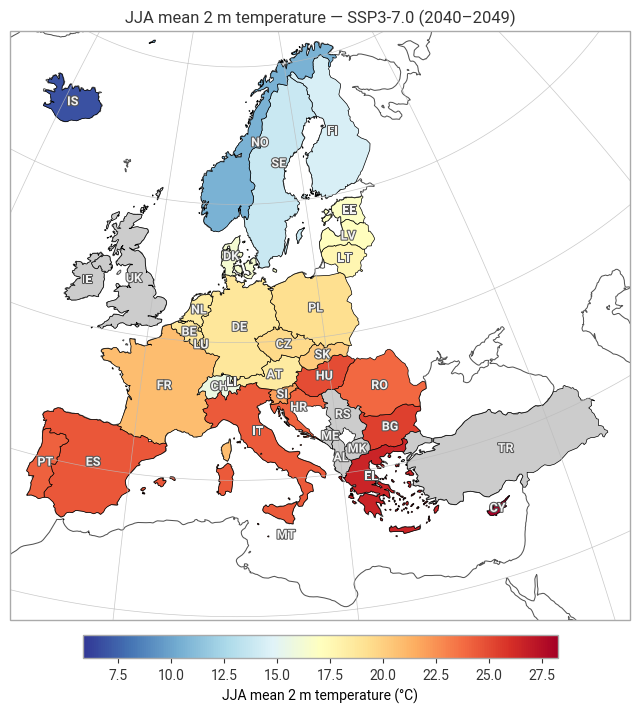

In [16]:
# ── Plot present and future JJA temperature side-by-side ─────────────────────
def plot_temp_map(geo_codes, temps_C, title, cmap_name="RdYlBu_r", norm_obj=None):
    if norm_obj is None:
        norm_obj = plt.Normalize(vmin=np.nanmin(temps_C), vmax=np.nanmax(temps_C))
    cmap_obj = plt.get_cmap(cmap_name)
    df_t = pd.DataFrame({"geo": geo_codes, "temp": temps_C})
    df_t["facecolor"] = df_t["temp"].apply(
        lambda x: plt.cm.colors.to_hex(cmap_obj(norm_obj(x)))
        if not np.isnan(x) else "#cccccc"
    )
    gdf_t = gdf.merge(df_t, left_on="NUTS_ID", right_on="geo", how="left")
    if not isinstance(gdf_t, gpd.GeoDataFrame):
        gdf_t = gpd.GeoDataFrame(gdf_t, geometry=gdf.geometry, crs=gdf.crs)
    gdf_t["facecolor"] = gdf_t["facecolor"].fillna("#cccccc")
    chart = earthkit.plots.Map(domain="Europe")
    chart.coastlines()
    chart.shapes(shapefile_path, labels="NUTS_ID", facecolor=gdf_t["facecolor"],
                 cmap=cmap_name, edgecolor="black", linewidth=0.5)
    chart.gridlines(draw_labels=False)
    chart.title(title)
    sm = plt.cm.ScalarMappable(cmap=cmap_name, norm=norm_obj)
    sm.set_array([])
    chart.fig.colorbar(sm, ax=chart.ax, orientation="horizontal",
                       pad=0.02, shrink=0.6, label="JJA mean 2 m temperature (°C)")
    chart.show()

# Shared colour scale so both maps are directly comparable
norm_temp = plt.Normalize(
    vmin=min(T_hist_C.min(), T_future_C.min()),
    vmax=max(T_hist_C.max(), T_future_C.max()),
)

plot_temp_map(country_codes, T_hist_C,
              "JJA mean 2 m temperature — Historical baseline (2005–2014)",
              norm_obj=norm_temp)
plot_temp_map(country_codes, T_future_C,
              "JJA mean 2 m temperature — SSP3-7.0 (2040–2049)",
              norm_obj=norm_temp)

---
## Part 3 — Habitat shift map

The thermal envelope of *Quercus robur* is estimated from the Climate DT historical temperatures in countries where the species is currently recorded (GBIF count > threshold).  Each country is then categorised:

| Category | Meaning |
|---|---|
| **Current range** | GBIF occurrences present; historical temp within envelope |
| **Range expansion** | No/few GBIF occurrences; future temp now within the envelope |
| **Range loss** | GBIF occurrences present; future temp outside the envelope |
| **Outside range** | Neither present nor future temp within the envelope |

In [17]:
# ── Derive thermal envelope from countries with GBIF observations ─────────────
# A country is considered "occupied" if it has more than MIN_OCC occurrences.
MIN_OCC = 500

gbif_map = df_gbif.set_index("geo")["occurrences"].to_dict()
occ_arr  = np.array([gbif_map.get(c, 0) for c in country_codes])
occupied = occ_arr >= MIN_OCC

# Thermal envelope = [min, max] JJA temp across occupied countries
envelope_min = T_hist_C[occupied].min()
envelope_max = T_hist_C[occupied].max()

print(f"Countries with >= {MIN_OCC:,} occurrences: "
      f"{[c for c, o in zip(country_codes, occupied) if o]}")
print(f"Thermal envelope (JJA hist): {envelope_min:.1f} °C – {envelope_max:.1f} °C")

Countries with >= 500 occurrences: ['BE', 'CZ', 'DK', 'DE', 'EE', 'ES', 'FR', 'IT', 'LT', 'LU', 'NL', 'AT', 'PL', 'PT', 'SK', 'FI', 'SE', 'NO', 'CH']
Thermal envelope (JJA hist): 8.7 °C – 23.1 °C


In [18]:
# ── Classify each country ─────────────────────────────────────────────────────
def in_envelope(temp, lo, hi, margin=0.0):
    return lo - margin <= temp <= hi + margin

categories = []
for i, code in enumerate(country_codes):
    hist_in   = in_envelope(T_hist_C[i],   envelope_min, envelope_max)
    future_in = in_envelope(T_future_C[i], envelope_min, envelope_max)
    is_occ    = occupied[i]

    if is_occ and hist_in and future_in:
        cat = "current_range"      # still suitable in future
    elif is_occ and hist_in and not future_in:
        cat = "range_loss"         # too hot (or too cold) in future
    elif not is_occ and not hist_in and future_in:
        cat = "range_expansion"    # newly suitable in future
    elif is_occ and not hist_in:
        # Occupied but already outside envelope — treat as current range
        # (coarse country-level temp is an approximation)
        cat = "current_range"
    else:
        cat = "outside_range"
    categories.append(cat)

df_habitat = pd.DataFrame({
    "geo":       country_codes,
    "T_hist":    T_hist_C,
    "T_future":  T_future_C,
    "delta_T":   T_future_C - T_hist_C,
    "occ":       occ_arr,
    "occupied":  occupied,
    "category":  categories,
})
print(df_habitat[["geo", "T_hist", "T_future", "delta_T", "occ", "category"]]
      .to_string(index=False))

geo    T_hist  T_future  delta_T    occ      category
 BE 16.910476 18.731060 1.820584  52645 current_range
 BG 22.484979 25.394799 2.909820     63 outside_range
 CZ 17.283545 19.498181 2.214636   8294 current_range
 DK 14.781042 16.258649 1.477607 101765 current_range
 DE 16.847264 18.736260 1.888996 260734 current_range
 EE 14.814090 16.786881 1.972791   3725 current_range
 EL 24.197162 26.486549 2.289387     89 outside_range
 ES 22.877138 24.501770 1.624633  11895    range_loss
 FR 18.927253 20.836085 1.908832 324428 current_range
 HR 21.184729 24.060589 2.875860     67 outside_range
 IT 22.183013 24.426011 2.242998   1586    range_loss
 CY 26.947452 28.231689 1.284237      0 outside_range
 LV 15.105256 17.064637 1.959380    336 outside_range
 LT 15.753644 17.692547 1.938903    627 current_range
 LU 17.019607 19.095616 2.076009   4195 current_range
 HU 21.975015 24.966797 2.991783    272 outside_range
 NL 16.618243 18.355409 1.737166 190294 current_range
 AT 16.185629 18.460945 2.27

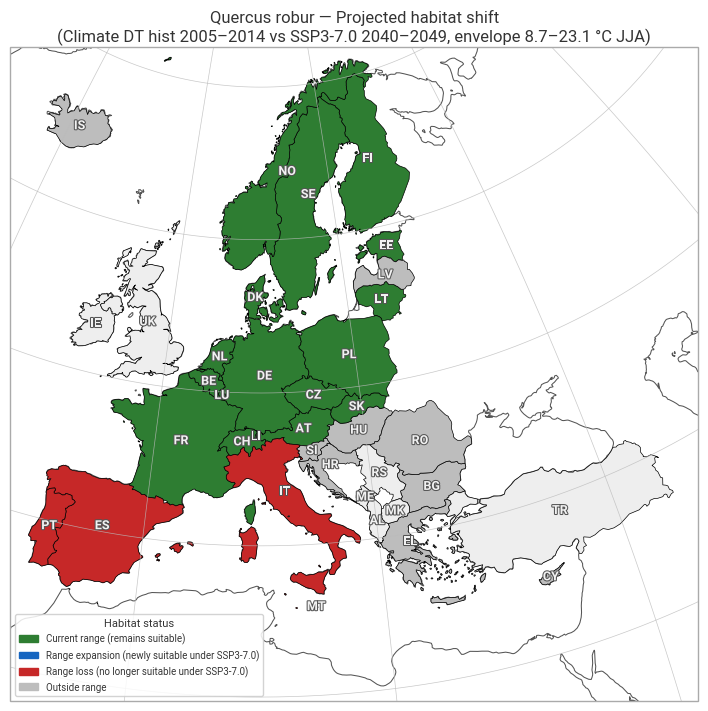

In [19]:
# ── Plot habitat shift map ────────────────────────────────────────────────────
CAT_COLOURS = {
    "current_range":   "#2e7d32",   # dark green  — present and suitable
    "range_expansion": "#1565c0",   # dark blue   — newly suitable
    "range_loss":      "#c62828",   # dark red    — no longer suitable
    "outside_range":   "#bdbdbd",   # grey        — neither
}
CAT_LABELS = {
    "current_range":   "Current range (remains suitable)",
    "range_expansion": "Range expansion (newly suitable under SSP3-7.0)",
    "range_loss":      "Range loss (no longer suitable under SSP3-7.0)",
    "outside_range":   "Outside range",
}

df_habitat["facecolor"] = df_habitat["category"].map(CAT_COLOURS)

gdf_habitat = gdf.merge(df_habitat, left_on="NUTS_ID", right_on="geo", how="left")
if not isinstance(gdf_habitat, gpd.GeoDataFrame):
    gdf_habitat = gpd.GeoDataFrame(gdf_habitat, geometry=gdf.geometry, crs=gdf.crs)
gdf_habitat["facecolor"] = gdf_habitat["facecolor"].fillna("#eeeeee")

chart = earthkit.plots.Map(domain="Europe")
chart.coastlines()
chart.shapes(
    shapefile_path,
    labels="NUTS_ID",
    facecolor=gdf_habitat["facecolor"],
    edgecolor="black",
    linewidth=0.5,
)
chart.gridlines(draw_labels=False)
chart.title(
    f"Quercus robur — Projected habitat shift\n"
    f"(Climate DT hist 2005–2014 vs SSP3-7.0 2040–2049, "
    f"envelope {envelope_min:.1f}–{envelope_max:.1f} °C JJA)"
)

# Manual legend
patches = [
    mpatches.Patch(color=col, label=CAT_LABELS[cat])
    for cat, col in CAT_COLOURS.items()
]
chart.ax.legend(
    handles=patches,
    loc="lower left",
    fontsize=7,
    framealpha=0.85,
    title="Habitat status",
    title_fontsize=8,
)
chart.show()

In [20]:
# ── Summary table ─────────────────────────────────────────────────────────────
summary = (
    df_habitat[["geo", "T_hist", "T_future", "delta_T", "occ", "category"]]
    .sort_values("category")
    .reset_index(drop=True)
)
summary.columns = [
    "Country", "T hist JJA (°C)", "T future JJA (°C)",
    "ΔT (°C)", "GBIF occurrences", "Category"
]

def colour_row(row):
    c = CAT_COLOURS.get(df_habitat.loc[
        df_habitat["geo"] == row["Country"], "category"].values[0], "white")
    return [f"background-color: {c}22"] * len(row)

summary.style.apply(colour_row, axis=1).format({
    "T hist JJA (°C)":   "{:.1f}",
    "T future JJA (°C)": "{:.1f}",
    "ΔT (°C)":           "{:+.1f}",
    "GBIF occurrences":  "{:,}",
})

,Country,T hist JJA (°C),T future JJA (°C),ΔT (°C),GBIF occurrences,Category
0,BE,16.9,18.7,+1.8,"52,645",current_range
1,SE,12.0,13.9,+1.9,"212,822",current_range
2,FI,12.4,14.5,+2.1,"13,421",current_range
3,SK,17.8,20.2,+2.5,"3,578",current_range
4,PL,17.3,19.3,+2.0,"46,190",current_range
5,AT,16.2,18.5,+2.3,"22,854",current_range
6,NL,16.6,18.4,+1.7,"190,294",current_range
7,LU,17.0,19.1,+2.1,"4,195",current_range
8,NO,8.7,10.6,+1.9,"19,803",current_range
9,LT,15.8,17.7,+1.9,627,current_range
